In [24]:

import pandas as pd

# Carregando dataset
df_url = pd.read_csv("../data/datasetURL.csv")

# Verificando dataframe
df_url.head()

,url,label,source
0,http://110.37.26.193:54956/bin.sh,1,urlhaus
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus
4,https://bronze.systems,0,tranco


In [25]:
# Obtendo informações sobre as colunas e tipos presentes no df_url
df_url.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48812 entries, 0 to 48811
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     48812 non-null  object
 1   label   48812 non-null  int64 
 2   source  48812 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [26]:
# Verificando a quantidade de valores nulos por coluna
df_url.isnull().sum()

url       0
label     0
source    0
dtype: int64

In [27]:
# Verificando a distribuição das colunas
df_url["label"].value_counts()

label
1    24406
0    24406
Name: count, dtype: int64

Embora o dataset seja descrito como contendo 100.000 URLs, a versão utilizada apresentou 99.036 registros válidos. Apesar disso, as classes estão praticamente balanceadas, apresentando uma diferença de apenas 964 urls. Além disso, não há valores nulos, portanto, não haverá necessidade de fazer tratamento de dados faltantes.

In [28]:
# Checando se há linhas duplicadas
df_url.duplicated().sum()

np.int64(0)

In [34]:
df_url["url_length"] = df_url["url"].str.len()

In [35]:
df_url["url_length"].describe()

count    48812.000000
mean        28.076641
std         13.997965
min         12.000000
25%         20.000000
50%         26.000000
75%         33.000000
max        891.000000
Name: url_length, dtype: float64

In [36]:
df_url.groupby("label")["url_length"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,24406.0,20.025035,3.675161,12.0,17.0,20.0,22.0,64.0
1,24406.0,36.128247,15.771024,15.0,29.0,33.0,37.0,891.0


In [37]:
df_url.nlargest(10, "url_length")[["url", "label", "url_length"]]

,url,label,url_length
23601,https://release-assets.githubusercontent.com/g...,1,891
39153,http://5.206.227.156/Documents/invoice.pdf%20%...,1,286
34807,http://ykapi.luyou.360.cn/rule/check?ckey=SZAT...,1,256
38332,https://download1475.mediafire.com/ztl0gmo5lps...,1,249
24018,https://download2302.mediafire.com/ktp54x0702q...,1,242
45694,https://wangsa888.org/.tmb/body.html?js=true&b...,1,241
28549,https://raw.githubusercontent.com/nwekar666/Ho...,1,238
9731,https://download2302.mediafire.com/ffs7xbah40p...,1,235
19648,https://download1348.mediafire.com/ktrbw729kdr...,1,235
33972,https://download1348.mediafire.com/n7r1afz05k7...,1,235


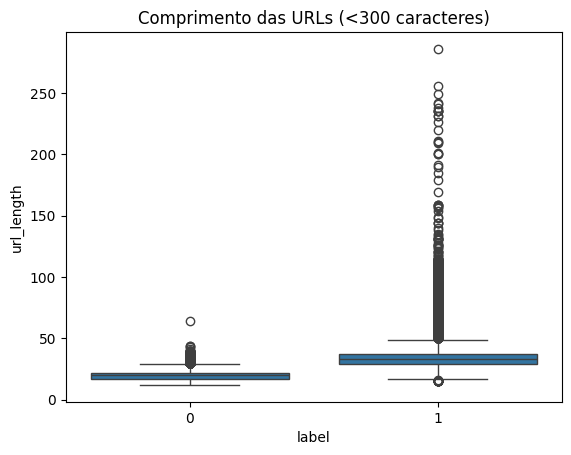

In [48]:
import seaborn as sns

sns.boxplot(
    data=df_url[df_url["url_length"] < 300],
    x="label",
    y="url_length"
)

plt.title("Comprimento das URLs (<300 caracteres)")
plt.show()

In [49]:
df_url["uses_https"] = df_url["url"].str.startswith("https")

In [50]:
pd.crosstab(
    df_url["uses_https"],
    df_url["label"],
    normalize="columns"
) * 100

label,0,1
uses_https,,
False,0.0,77.013849
True,100.0,22.986151


In [51]:
df_url["num_dots"] = df_url["url"].str.count(r"\.")

In [52]:
df_url.groupby("label")["num_dots"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,24406.0,1.074859,0.264566,1.0,1.0,1.0,1.0,3.0
1,24406.0,3.177661,0.887105,1.0,3.0,3.0,4.0,17.0


In [53]:
df_url["num_dots"] = df_url["url"].str.count(r"\.")

In [54]:
df_url.groupby("label")["num_dots"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,24406.0,1.074859,0.264566,1.0,1.0,1.0,1.0,3.0
1,24406.0,3.177661,0.887105,1.0,3.0,3.0,4.0,17.0


In [57]:
df_url["source"].value_counts()

source
tranco       24406
urlhaus      24106
openphish      300
Name: count, dtype: int64